# IT549 Lab 3 — AQI Image Classification

### Name: Dhruv Patel
### ID: 202301095

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from pathlib import Path

# TODO: set this to the folder containing data.csv
# Example: DATA_ROOT = Path('/content/drive/MyDrive/IT549_Lab3_AQI')
DATA_ROOT = Path('/content/drive/MyDrive/DL_Assignment_3')
CSV_PATH = DATA_ROOT / 'data.csv'

print('DATA_ROOT:', DATA_ROOT)
print('CSV_PATH:', CSV_PATH)

DATA_ROOT: /content/drive/MyDrive/DL_Assignment_3
CSV_PATH: /content/drive/MyDrive/DL_Assignment_3/data.csv


## Data preparation
This section loads the CSV, resolves image files, and creates a reproducible 70/15/15 split.

In [ ]:
import random
import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

import matplotlib.pyplot as plt
import seaborn as sns

def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

SEED = 42
seed_everything(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [ ]:
df = pd.read_csv(CSV_PATH)
print('CSV columns:', list(df.columns))

LABEL_COL = 'AQI_Class'
if LABEL_COL not in df.columns:
    raise ValueError(f'Missing label column: {LABEL_COL}')

if 'Filename' in df.columns:
    IMG_COL = 'Filename'
else:
    raise ValueError('Expected image_path or Filename column in CSV')

df = df[[IMG_COL, LABEL_COL]].copy()
df[IMG_COL] = df[IMG_COL].astype(str)
df[LABEL_COL] = df[LABEL_COL].astype(str)
df.head()

CSV columns: ['Filename', 'AQI', 'PM2.5', 'PM10', 'O3', 'CO', 'SO2', 'NO2', 'AQI_Class']


,Filename,AQI_Class
0,BENGR_Good_2023-03-25-08.30-1-43.jpg,a_Good
1,BENGR_Good_2023-02-28-08.30-1-11.jpg,a_Good
2,BENGR_Good_2023-02-28-08.30-1-551.jpg,a_Good
3,TN_Good_2023-02-27-16.30-1-196.jpg,a_Good
4,BENGR_Good_2023-02-27-08.30-1-276.jpg,a_Good


In [ ]:
# Resolve images: supports full paths, relative paths, and Filename without extension
IMG_DIR = DATA_ROOT / 'sampled_images'
exts = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

roots = [IMG_DIR] if IMG_DIR.exists() else [DATA_ROOT]
image_files = []
for root in roots:
    image_files.extend([p for p in root.rglob('*') if p.suffix.lower() in exts])

by_name = {p.name: p for p in image_files}
by_stem = {p.stem: p for p in image_files}

def resolve_image(ref: str) -> Path:
    ref = str(ref).replace('\\', '/')
    p = Path(ref)

    # absolute path
    if p.is_absolute() and p.exists():
        return p

    # relative path
    cand = (DATA_ROOT / p).resolve()
    if cand.exists():
        return cand

    # lookup by name/stem
    if p.name in by_name:
        return by_name[p.name]
    if p.stem in by_stem:
        return by_stem[p.stem]

    # try adding common extensions if missing
    if p.suffix == '':
        for e in ['.jpg', '.jpeg', '.png']:
            key = p.name + e
            if key in by_name:
                return by_name[key]
            key2 = p.stem + e
            if key2 in by_name:
                return by_name[key2]

    return cand

resolved = df[IMG_COL].apply(resolve_image)
exists_mask = resolved.apply(lambda p: p.exists())
print('Missing images:', int((~exists_mask).sum()), 'out of', len(df))

df = df.loc[exists_mask].reset_index(drop=True)
df['resolved_path'] = resolved.loc[exists_mask].astype(str).values
print('Remaining rows:', len(df))
df.head()

Missing images: 0 out of 6000
Remaining rows: 6000


,Filename,AQI_Class,resolved_path
0,BENGR_Good_2023-03-25-08.30-1-43.jpg,a_Good,/content/drive/MyDrive/DL_Assignment_3/sampled...
1,BENGR_Good_2023-02-28-08.30-1-11.jpg,a_Good,/content/drive/MyDrive/DL_Assignment_3/sampled...
2,BENGR_Good_2023-02-28-08.30-1-551.jpg,a_Good,/content/drive/MyDrive/DL_Assignment_3/sampled...
3,TN_Good_2023-02-27-16.30-1-196.jpg,a_Good,/content/drive/MyDrive/DL_Assignment_3/sampled...
4,BENGR_Good_2023-02-27-08.30-1-276.jpg,a_Good,/content/drive/MyDrive/DL_Assignment_3/sampled...


In [ ]:
# Encode labels
class_names = sorted(df[LABEL_COL].unique().tolist())
class_to_idx = {c: i for i, c in enumerate(class_names)}
df['label_idx'] = df[LABEL_COL].map(class_to_idx)

print('Classes:', class_names)
df[LABEL_COL].value_counts()

Classes: ['a_Good', 'b_Moderate', 'c_Unhealthy_for_Sensitive_Groups', 'd_Unhealthy', 'e_Very_Unhealthy', 'f_Severe']


,count
AQI_Class,
a_Good,1000
b_Moderate,1000
c_Unhealthy_for_Sensitive_Groups,1000
d_Unhealthy,1000
e_Very_Unhealthy,1000
f_Severe,1000


In [ ]:
# 70/15/15 split (stratified)
train_df, temp_df = train_test_split(
    df, test_size=0.30, random_state=SEED, stratify=df['label_idx']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, random_state=SEED, stratify=temp_df['label_idx']
)
print('Train/Val/Test:', len(train_df), len(val_df), len(test_df))

Train/Val/Test: 4200 900 900


### Preprocessing (resize + normalize)


In [ ]:
IMAGE_SIZE = 224
BATCH_SIZE = 32

transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

In [ ]:
class AQIDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=None):
        self.paths = df['resolved_path'].tolist()
        self.labels = df['label_idx'].tolist()
        self.transform = transform

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        path = self.paths[idx]
        y = self.labels[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(y, dtype=torch.long), path

train_ds = AQIDataset(train_df, transform)
val_ds   = AQIDataset(val_df, transform)
test_ds  = AQIDataset(test_df, transform)

# Drive reading is most reliable with num_workers=0
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

next(iter(train_loader))[0].shape

torch.Size([32, 3, 224, 224])

## Training + Evaluation

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for x, y, _paths in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def eval_one_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for x, y, _paths in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)
        total_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)
    return total_loss / total, correct / total

def fit(model, train_loader, val_loader, epochs=10, lr=1e-3):
    model = model.to(device)
    optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_acc = -1.0
    best_state = None
    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = eval_one_epoch(model, val_loader, criterion)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(va_loss)
        history['train_acc'].append(tr_acc)
        history['val_acc'].append(va_acc)
        if va_acc > best_val_acc:
            best_val_acc = va_acc
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        print(f'Epoch {epoch:02d}/{epochs} | train loss {tr_loss:.4f} acc {tr_acc:.4f} | val loss {va_loss:.4f} acc {va_acc:.4f}')
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history

@torch.no_grad()
def predict(model, loader):
    model.eval()
    y_true, y_pred, paths = [], [], []
    for x, y, p in loader:
        x = x.to(device)
        logits = model(x)
        preds = logits.argmax(1).cpu().numpy().tolist()
        y_true.extend(y.cpu().numpy().tolist())
        y_pred.extend(preds)
        paths.extend(list(p))
    return np.array(y_true), np.array(y_pred), paths

def metrics_and_confusion(y_true, y_pred, class_names):
    acc = accuracy_score(y_true, y_pred)
    p, r, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    report = classification_report(y_true, y_pred, target_names=class_names, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    return acc, p, r, f1, report, cm

def plot_curves(history, title):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(title)
    ax[0].plot(epochs, history['train_loss'], label='train')
    ax[0].plot(epochs, history['val_loss'], label='val')
    ax[0].set_title('Loss')
    ax[0].set_xlabel('Epoch')
    ax[0].legend()
    ax[1].plot(epochs, history['train_acc'], label='train')
    ax[1].plot(epochs, history['val_acc'], label='val')
    ax[1].set_title('Accuracy')
    ax[1].set_xlabel('Epoch')
    ax[1].legend()
    plt.show()

def plot_cm(cm, class_names, title):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(title)
    plt.show()

def show_misclassified(paths, y_true, y_pred, class_names, max_images=10, title='Misclassified'):
    wrong = np.where(y_true != y_pred)[0][:max_images]
    if len(wrong) == 0:
        print('No misclassifications found.')
        return
    cols = 5
    rows = int(np.ceil(len(wrong) / cols))
    plt.figure(figsize=(cols * 3, rows * 3))
    for i, idx in enumerate(wrong, start=1):
        img = Image.open(paths[idx]).convert('RGB')
        plt.subplot(rows, cols, i)
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'pred: {class_names[y_pred[idx]]}\ntrue: {class_names[y_true[idx]]}')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

## Basic CNN

In [ ]:
class BasicCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128 * 28 * 28, num_classes),
        )
    def forward(self, x):
        return self.net(x)

EPOCHS = 5
LR = 1e-3

basic = BasicCNN(num_classes=len(class_names))
basic, basic_hist = fit(basic, train_loader, val_loader, epochs=EPOCHS, lr=LR)

Epoch 01/5 | train loss 1.3689 acc 0.4593 | val loss 1.0320 acc 0.5911
Epoch 02/5 | train loss 0.9233 acc 0.6505 | val loss 0.8278 acc 0.6611
Epoch 03/5 | train loss 0.6064 acc 0.7776 | val loss 0.8490 acc 0.7089
Epoch 04/5 | train loss 0.4581 acc 0.8350 | val loss 0.6636 acc 0.7756
Epoch 05/5 | train loss 0.3303 acc 0.8838 | val loss 0.6141 acc 0.7911


Basic CNN — Test Metrics
Accuracy: 0.7777777777777778
Precision (weighted): 0.7947039708566712
Recall (weighted): 0.7777777777777778
F1 (weighted): 0.7792811065162677

Classification report:

                                  precision    recall  f1-score   support

                          a_Good       0.81      0.80      0.80       150
                      b_Moderate       0.61      0.89      0.72       150
c_Unhealthy_for_Sensitive_Groups       0.70      0.67      0.69       150
                     d_Unhealthy       0.82      0.62      0.70       150
                e_Very_Unhealthy       0.90      0.81      0.85       150
                        f_Severe       0.94      0.87      0.90       150

                        accuracy                           0.78       900
                       macro avg       0.79      0.78      0.78       900
                    weighted avg       0.79      0.78      0.78       900



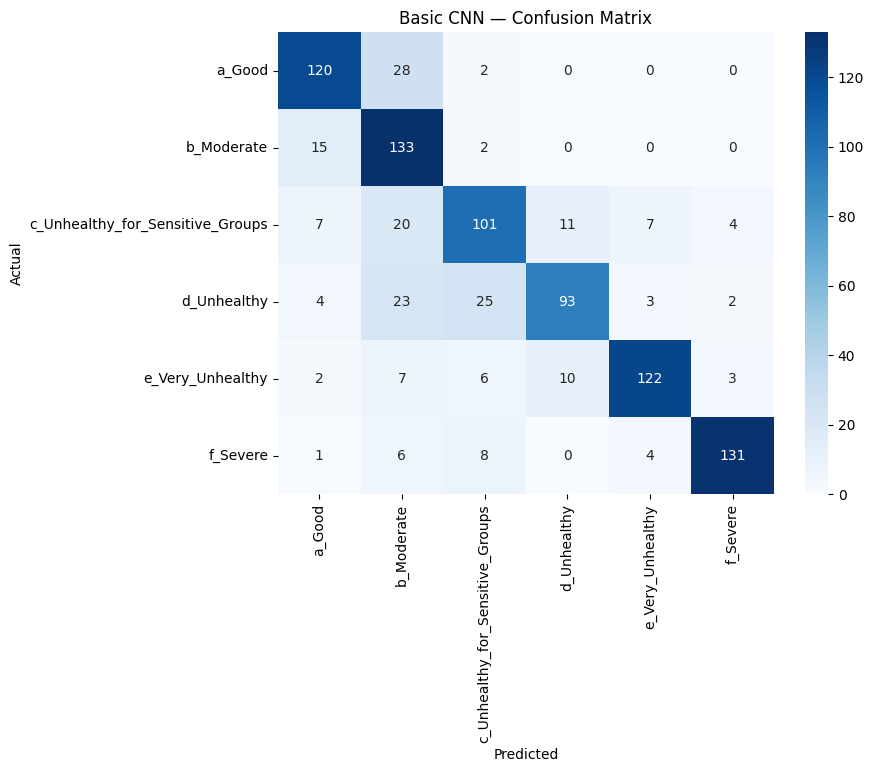

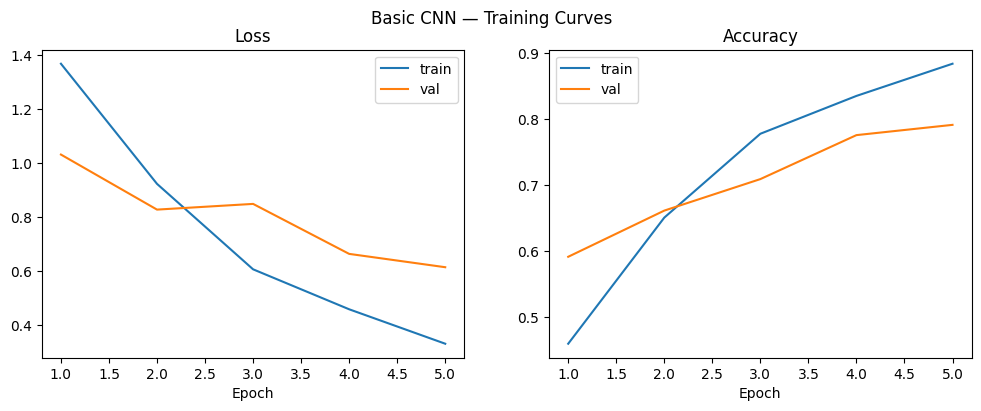

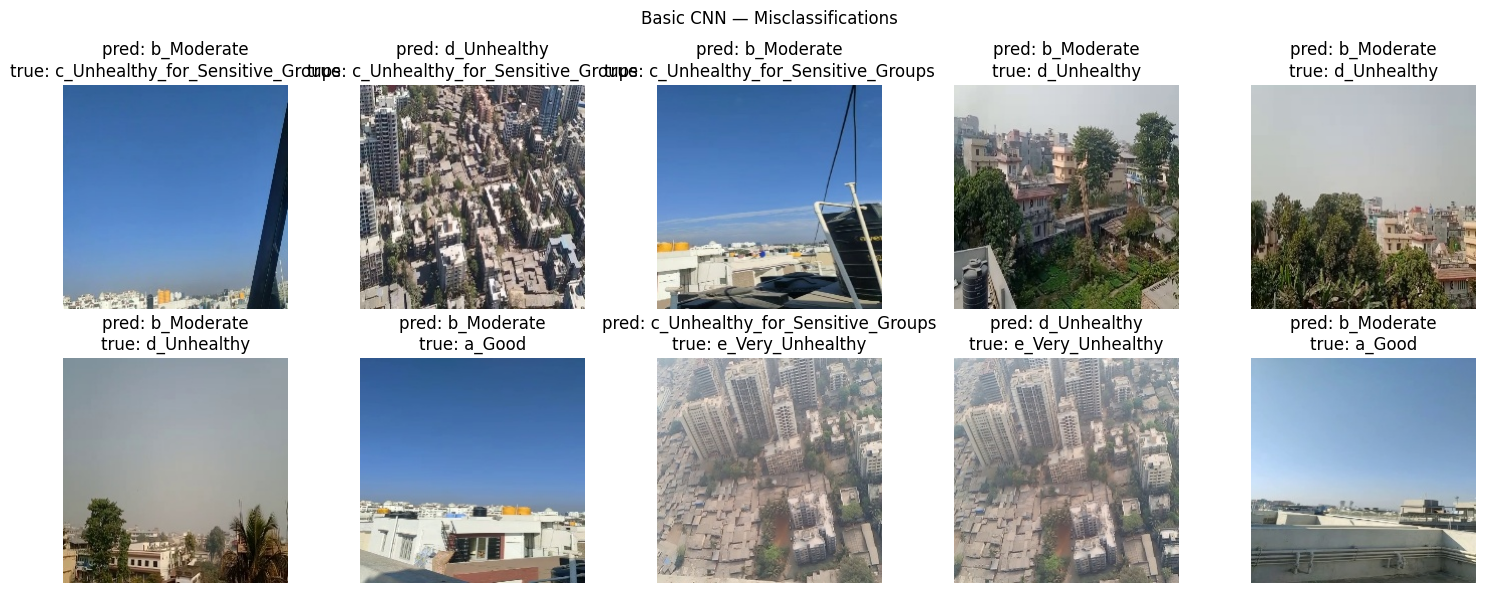

In [ ]:
y_true_b, y_pred_b, paths_b = predict(basic, test_loader)
acc_b, p_b, r_b, f1_b, report_b, cm_b = metrics_and_confusion(y_true_b, y_pred_b, class_names)

print('Basic CNN — Test Metrics')
print('Accuracy:', acc_b)
print('Precision (weighted):', p_b)
print('Recall (weighted):', r_b)
print('F1 (weighted):', f1_b)
print('\nClassification report:\n')
print(report_b)

plot_cm(cm_b, class_names, title='Basic CNN — Confusion Matrix')
plot_curves(basic_hist, title='Basic CNN — Training Curves')
show_misclassified(paths_b, y_true_b, y_pred_b, class_names, max_images=10, title='Basic CNN — Misclassifications')

## Transfer learning (pretrained ResNet18)
We replace the last layer and train only the classifier head.

In [ ]:
try:
    weights = models.ResNet18_Weights.DEFAULT
    transfer = models.resnet18(weights=weights)
except Exception:
    transfer = models.resnet18(pretrained=True)

for p in transfer.parameters():
    p.requires_grad = False

in_features = transfer.fc.in_features
transfer.fc = nn.Linear(in_features, len(class_names))
for p in transfer.fc.parameters():
    p.requires_grad = True

transfer, transfer_hist = fit(transfer, train_loader, val_loader, epochs=EPOCHS, lr=LR)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 195MB/s]


Epoch 01/5 | train loss 1.3771 acc 0.4750 | val loss 1.0739 acc 0.6133
Epoch 02/5 | train loss 1.0150 acc 0.6364 | val loss 0.8881 acc 0.6867
Epoch 03/5 | train loss 0.8764 acc 0.6845 | val loss 0.8161 acc 0.6978
Epoch 04/5 | train loss 0.8052 acc 0.7193 | val loss 0.7249 acc 0.7467
Epoch 05/5 | train loss 0.7387 acc 0.7333 | val loss 0.6771 acc 0.7667


Transfer (ResNet18) — Test Metrics
Accuracy: 0.7222222222222222
Precision (weighted): 0.721011575658796
Recall (weighted): 0.7222222222222222
F1 (weighted): 0.7182458234819127

Classification report:

                                  precision    recall  f1-score   support

                          a_Good       0.70      0.60      0.65       150
                      b_Moderate       0.65      0.69      0.67       150
c_Unhealthy_for_Sensitive_Groups       0.64      0.53      0.58       150
                     d_Unhealthy       0.65      0.77      0.70       150
                e_Very_Unhealthy       0.85      0.79      0.82       150
                        f_Severe       0.84      0.96      0.89       150

                        accuracy                           0.72       900
                       macro avg       0.72      0.72      0.72       900
                    weighted avg       0.72      0.72      0.72       900



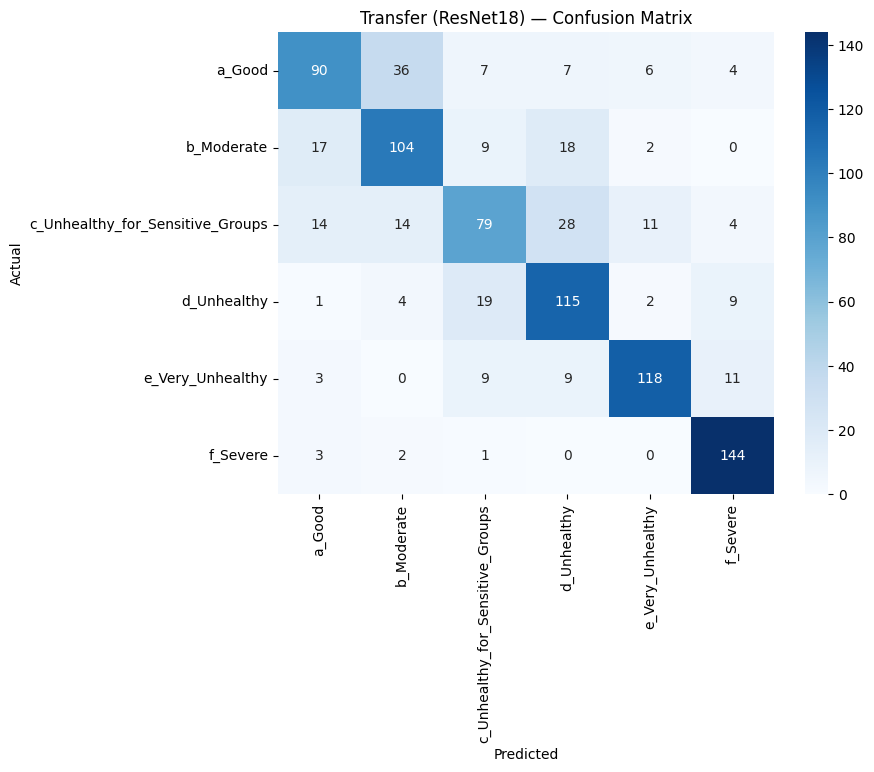

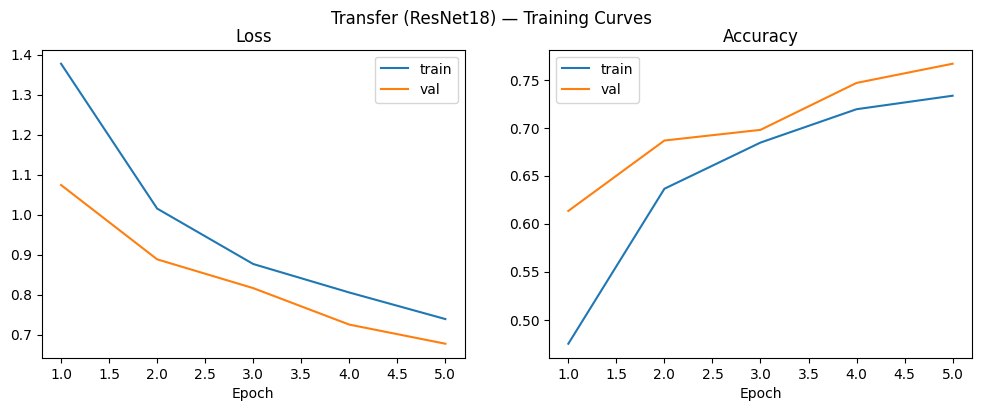

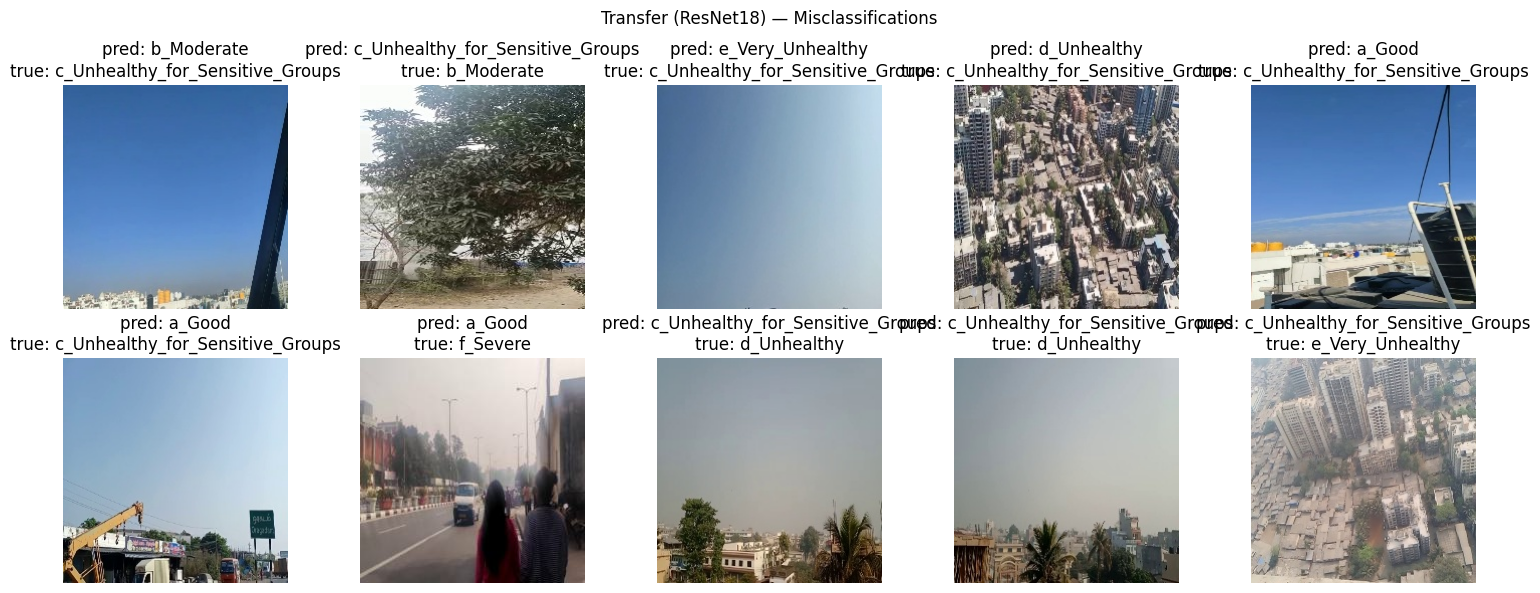

In [ ]:
y_true_t, y_pred_t, paths_t = predict(transfer, test_loader)
acc_t, p_t, r_t, f1_t, report_t, cm_t = metrics_and_confusion(y_true_t, y_pred_t, class_names)

print('Transfer (ResNet18) — Test Metrics')
print('Accuracy:', acc_t)
print('Precision (weighted):', p_t)
print('Recall (weighted):', r_t)
print('F1 (weighted):', f1_t)
print('\nClassification report:\n')
print(report_t)

plot_cm(cm_t, class_names, title='Transfer (ResNet18) — Confusion Matrix')
plot_curves(transfer_hist, title='Transfer (ResNet18) — Training Curves')
show_misclassified(paths_t, y_true_t, y_pred_t, class_names, max_images=10, title='Transfer (ResNet18) — Misclassifications')

## Comparison summary (Task 3 + Deliverable)
Compare scratch CNN vs transfer learning on the test set.

In [ ]:
results = pd.DataFrame([
    {'model': 'Basic CNN', 'accuracy': acc_b, 'precision_w': p_b, 'recall_w': r_b, 'f1_w': f1_b},
    {'model': 'Transfer ResNet18', 'accuracy': acc_t, 'precision_w': p_t, 'recall_w': r_t, 'f1_w': f1_t},
])
results